Using device: mps
Loading model...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:07<00:00, 43.21it/s, Materializing param=model.norm.weight]                              


Model has 28 hidden layers.

Loading dataset...
Loaded 500 samples.

Running model — collecting hidden states for all layers...


100%|██████████| 500/500 [31:07<00:00,  3.74s/it]



Collected 500 valid samples.
Correct: 201 / 500 (40.2%)

Saved per-sample results to results.json
Training probes across all layers...


100%|██████████| 28/28 [00:05<00:00,  5.10it/s]



Layer-wise probe accuracies:
  Layer  1: 0.660  ██████████████████████████
  Layer  2: 0.650  █████████████████████████
  Layer  3: 0.570  ████████████████
  Layer  4: 0.590  ██████████████████
  Layer  5: 0.620  █████████████████████
  Layer  6: 0.630  ███████████████████████
  Layer  7: 0.600  ███████████████████
  Layer  8: 0.610  ████████████████████
  Layer  9: 0.640  ████████████████████████
  Layer 10: 0.670  ███████████████████████████
  Layer 11: 0.640  ████████████████████████
  Layer 12: 0.680  ████████████████████████████
  Layer 13: 0.650  █████████████████████████
  Layer 14: 0.650  █████████████████████████
  Layer 15: 0.710  ██████████████████████████████
  Layer 16: 0.630  ███████████████████████
  Layer 17: 0.680  ████████████████████████████
  Layer 18: 0.640  ████████████████████████
  Layer 19: 0.650  █████████████████████████
  Layer 20: 0.660  ██████████████████████████
  Layer 21: 0.650  █████████████████████████
  Layer 22: 0.660  ██████████████████████████
  

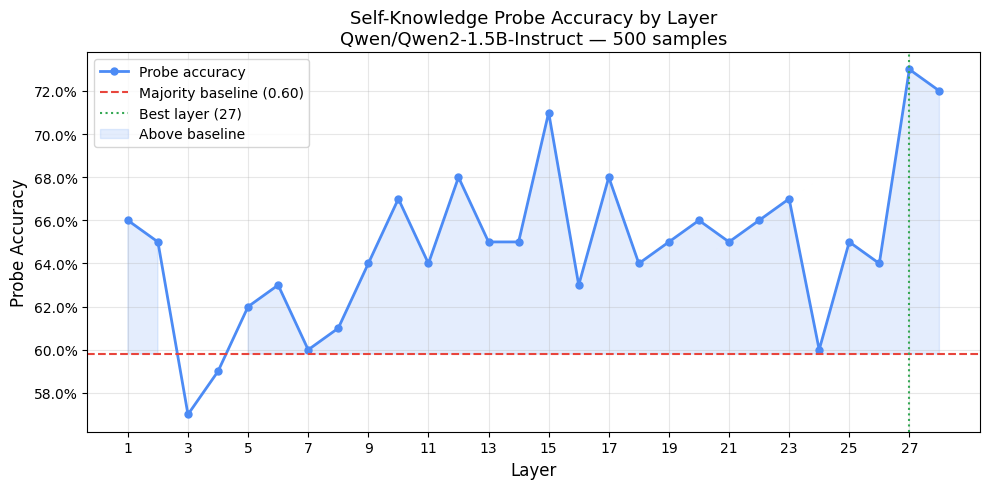

In [3]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from tqdm import tqdm

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
MODEL_NAME   = "Qwen/Qwen2-1.5B-Instruct"
NUM_SAMPLES  = 500
BATCH_SIZE   = 1
MAX_NEW_TOKENS = 50
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {DEVICE}")


# ─────────────────────────────────────────────
# STEP 1: Load model + tokenizer
# ─────────────────────────────────────────────
print("Loading model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    trust_remote_code=True,
)
model = model.to(DEVICE)
model.eval()

# Detect number of layers automatically
NUM_LAYERS = model.config.num_hidden_layers
print(f"Model has {NUM_LAYERS} hidden layers.\n")


# ─────────────────────────────────────────────
# STEP 2: Load dataset
# ─────────────────────────────────────────────
print("Loading dataset...")
dataset = load_dataset("trivia_qa", "rc.nocontext", split="validation")
dataset = dataset.select(range(NUM_SAMPLES))
print(f"Loaded {len(dataset)} samples.\n")


# ─────────────────────────────────────────────
# HELPER: correctness check
# ─────────────────────────────────────────────
def is_correct(model_answer: str, ground_truth_aliases: list[str]) -> bool:
    model_answer = model_answer.strip().lower()
    for alias in ground_truth_aliases:
        if alias.lower() in model_answer or model_answer in alias.lower():
            return True
    return False


# ─────────────────────────────────────────────
# HELPER: run one sample, return answer + ALL layer hidden states
# Returns: (answer_str, list of numpy arrays, one per layer)
# ─────────────────────────────────────────────
def get_answer_and_all_hidden_states(question: str):
    prompt = f"Answer the following question in a few words.\nQuestion: {question}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            output_hidden_states=True,
            return_dict_in_generate=True,
            do_sample=False,
        )

    generated_ids = outputs.sequences[0][input_len:]
    answer = tokenizer.decode(generated_ids, skip_special_tokens=True)

    # outputs.hidden_states: tuple over generated tokens
    #   each entry: tuple of tensors, one per layer (including embedding layer)
    #   shape per tensor: (batch=1, seq_len, hidden_dim)
    # We use the first generated token, all layers except embedding (index 0)
    first_token_hs = outputs.hidden_states[0]  # all layers for token 0

    # first_token_hs[0] = embedding layer — skip it
    # first_token_hs[1..NUM_LAYERS] = transformer layers 0..NUM_LAYERS-1
    layer_vectors = []
    for layer_idx in range(1, NUM_LAYERS + 1):
        vec = first_token_hs[layer_idx][0, -1, :].float().cpu().numpy()
        layer_vectors.append(vec)

    return answer, layer_vectors


# ─────────────────────────────────────────────
# STEP 3: Collect activations for ALL layers in one pass
# ─────────────────────────────────────────────
print("Running model — collecting hidden states for all layers...")

# all_hidden[layer_idx] = list of hidden vectors for that layer
all_hidden = [[] for _ in range(NUM_LAYERS)]
labels  = []
results = []

for sample in tqdm(dataset):
    question = sample["question"]
    aliases  = sample["answer"]["aliases"]

    try:
        answer, layer_vectors = get_answer_and_all_hidden_states(question)
        correct = is_correct(answer, aliases)

        for layer_idx, vec in enumerate(layer_vectors):
            all_hidden[layer_idx].append(vec)

        labels.append(int(correct))
        results.append({
            "question":     question,
            "model_answer": answer,
            "correct":      correct,
            "ground_truth": aliases[0] if aliases else "",
        })

    except Exception as e:
        # If a sample fails, append zeros so layer lists stay aligned
        for layer_idx in range(NUM_LAYERS):
            all_hidden[layer_idx].append(None)
        labels.append(None)
        print(f"Skipping sample: {e}")

# Filter out failed samples (None entries)
valid_mask = [i for i, l in enumerate(labels) if l is not None]
labels_clean = [labels[i] for i in valid_mask]

print(f"\nCollected {len(labels_clean)} valid samples.")
print(f"Correct: {sum(labels_clean)} / {len(labels_clean)} "
      f"({100*sum(labels_clean)/len(labels_clean):.1f}%)\n")

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved per-sample results to results.json")


# ─────────────────────────────────────────────
# STEP 4: Train a probe per layer, record accuracy
# ─────────────────────────────────────────────
y = np.array(labels_clean)
baseline = max(y.mean(), 1 - y.mean())

layer_accuracies = []

print("Training probes across all layers...")
for layer_idx in tqdm(range(NUM_LAYERS)):
    vecs = [all_hidden[layer_idx][i] for i in valid_mask]
    X = np.array(vecs)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    probe = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    probe.fit(X_train, y_train)
    acc = accuracy_score(y_test, probe.predict(X_test))
    layer_accuracies.append(acc)

print("\nLayer-wise probe accuracies:")
for i, acc in enumerate(layer_accuracies):
    bar = "█" * int((acc - 0.4) * 100)
    print(f"  Layer {i+1:>2}: {acc:.3f}  {bar}")

best_layer = int(np.argmax(layer_accuracies))
print(f"\nBest layer: {best_layer + 1} "
      f"(accuracy = {layer_accuracies[best_layer]:.3f})")
print(f"Majority baseline: {baseline:.3f}")
print(f"Best probe improvement over baseline: "
      f"{(layer_accuracies[best_layer] - baseline)*100:.1f}%")


# ─────────────────────────────────────────────
# STEP 5: Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(1, NUM_LAYERS + 1)
ax.plot(x, layer_accuracies, marker="o", markersize=5,
        linewidth=2, color="#4C8BF5", label="Probe accuracy")
ax.axhline(baseline, linestyle="--", color="#E8453C",
           linewidth=1.5, label=f"Majority baseline ({baseline:.2f})")
ax.axvline(best_layer + 1, linestyle=":", color="#34A853",
           linewidth=1.5, label=f"Best layer ({best_layer + 1})")

ax.fill_between(x, baseline, layer_accuracies,
                where=[a > baseline for a in layer_accuracies],
                alpha=0.15, color="#4C8BF5", label="Above baseline")

ax.set_xlabel("Layer", fontsize=12)
ax.set_ylabel("Probe Accuracy", fontsize=12)
ax.set_title(f"Self-Knowledge Probe Accuracy by Layer\n"
             f"{MODEL_NAME} — {len(labels_clean)} samples", fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_xticks(x[::2])  # every other layer to avoid crowding
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("layer_probe_accuracy.png", dpi=150)
print("\nPlot saved to layer_probe_accuracy.png")
plt.show()